# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

Research Question
Does economic development improve life expectancy?

Core variable:
X: GDP per capita(US dollar)
Y: Life expectancy(years)

Time range: 2015-2022

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
!pip3 install matplotlib
!pip3 install statsmodels

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

os.getcwd()
os.listdir()

# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
# YOUR CODE HERE

# 2. Acquire and load your primary dataset
# YOUR CODE HERE

/Users/abcd/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


['hw_3.ipynb']

In [3]:
gdp_url = (
    "http://api.worldbank.org/v2/"
    "country/all/"
    "indicator/NY.GDP.PCAP.CD"
    "?format=json"
    "&date=2015:2022"
    "&per_page=20000"
)

gdp_response = requests.get(gdp_url)

gdp_data = gdp_response.json()[1]
gdp_df = pd.DataFrame(
    gdp_data
)

### **Dataset Context & Relevance**

- **Dataset Source**
  My dataset was obtained from the World Bank Open Data via API.

  Pirmary Dataset:
    Indicator: GDDP per capita (US dollar)
    Indicator code: NY.GDP.PCAP.CD
  
  Secondary Dataset:
    Indicator: Life expectancy (years)
    Indicator: SP.DYN.LE00.IN

GDP per capita represents economic development, while life expectancy represents health outcomes. Thie project investigates whether higher econoomic development is associated with better health outcomes.

- *Write your source here*

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [4]:
# 1. Inspect data structure using pandas methods
gdp_df.info()
gdp_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2128 entries, 0 to 2127
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   indicator        2128 non-null   object 
 1   country          2128 non-null   object 
 2   countryiso3code  2128 non-null   object 
 3   date             2128 non-null   object 
 4   value            2069 non-null   float64
 5   unit             2128 non-null   object 
 6   obs_status       2128 non-null   object 
 7   decimal          2128 non-null   int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 133.1+ KB


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,1679.327622,,,1
1,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,1562.416175,,,1
2,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2020,1351.591669,,,1
3,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2019,1507.085600,,,1
4,"{'id': 'NY.GDP.PCAP.CD', 'value': 'GDP per cap...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2018,1552.073722,,,1


In [ ]:
# 2. Rename columns and select a clean subset
gdp_sub = gdp_df[["countryiso3code", "date", "value"]]

gdp_clean = gdp_sub.rename(columns = {"countryiso3code":"country", "date":"year", "value":"gdp_per_capita"})

gdp_clean.head()


,country,year,gdp_per_capita
0,AFE,2022,1679.327622
1,AFE,2021,1562.416175
2,AFE,2020,1351.591669
3,AFE,2019,1507.085600
4,AFE,2018,1552.073722


In [6]:
# 3. Filter row or column filters if necessary
# YOUR CODE HERE

In [7]:
# 4. Handle missing values (NaNs) if necessary
gdp_clean = gdp_clean.dropna()

### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [8]:
# 1. Load and clean the secondary dataset
life_url = ("http://api.worldbank.org/v2/"
    "country/all/"
    "indicator/SP.DYN.LE00.IN"
    "?format=json"
    "&date=2015:2022"
    "&per_page=20000"
)

life_response = requests.get(life_url)

life_data = life_response.json()[1]

life_df = pd.DataFrame(life_data)

life_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2128 entries, 0 to 2127
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   indicator        2128 non-null   object 
 1   country          2128 non-null   object 
 2   countryiso3code  2128 non-null   object 
 3   date             2128 non-null   object 
 4   value            2120 non-null   float64
 5   unit             2128 non-null   object 
 6   obs_status       2128 non-null   object 
 7   decimal          2128 non-null   int64  
dtypes: float64(1), int64(1), object(6)
memory usage: 133.1+ KB


In [9]:

life_sub = life_df[["countryiso3code", "date", "value"]]

life_clean = life_sub.rename(columns = {"countryiso3code":"country", "date":"year", "value":"life_expectancy"})

life_clean.head()

,country,year,life_expectancy
0,AFE,2022,64.487152
1,AFE,2021,62.979999
2,AFE,2020,63.766484
3,AFE,2019,63.857261
4,AFE,2018,63.330691


In [10]:
life_clean = life_clean.dropna()

In [11]:
# 2. Merge your datasets on a common key
merge_df = pd.merge(gdp_clean, life_clean, on = ["country", "year"], how = "inner")
merge_df.head()
merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2165 entries, 0 to 2164
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          2165 non-null   object 
 1   year             2165 non-null   object 
 2   gdp_per_capita   2165 non-null   float64
 3   life_expectancy  2165 non-null   float64
dtypes: float64(2), object(2)
memory usage: 67.8+ KB


### **Merge Verification**

- **Merge Key**
  - country and year
- **Observations Retained**
  - I kept 2165 rows after merging.

- I merge primary dataset and secondary dataset with key country and year. Only observations with both GDP per capita and life expectancy information were retained after merging.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [12]:
# Apply groupby aggregation or implement one of the backup grouping strategies
merge_df["income_group"] = pd.cut(merge_df["gdp_per_capita"], bins = [0,10000,30000,np.inf], labels = ["Low Income", "Middle Income", "High Income"])

In [13]:
income_summary = (merge_df.groupby("income_group")["life_expectancy"].mean())

income_summary

/var/folders/7b/90d195g946g151jgphktj8pc0000gp/T/ipykernel_17171/3366195666.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_summary = (merge_df.groupby("income_group")["life_expectancy"].mean())


income_group
Low Income       68.259031
Middle Income    76.131310
High Income      80.310698
Name: life_expectancy, dtype: float64

- Countries with higher GDP per capita show higher average life expectancy. This suggests that economic development improves people's health outcomes.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

<function matplotlib.pyplot.show(close=None, block=None)>

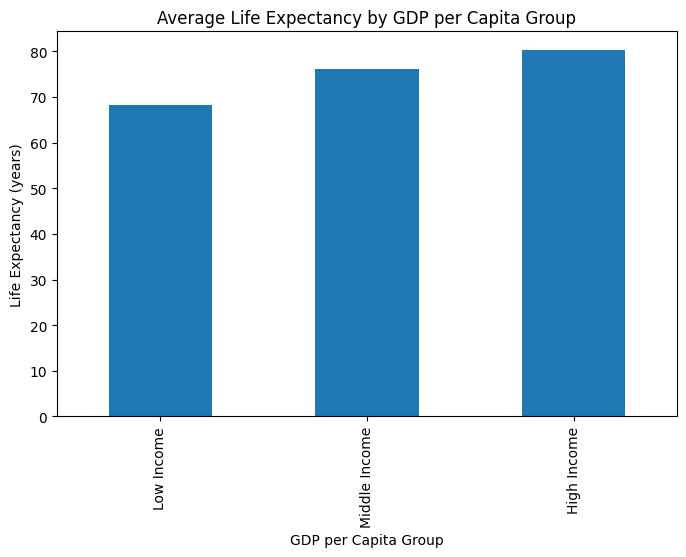

In [14]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
plt.figure(figsize = (8,5))

income_summary.plot(kind="bar")

plt.title("Average Life Expectancy by GDP per Capita Group")
plt.xlabel("GDP per Capita Group")
plt.ylabel("Life Expectancy (years)")

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

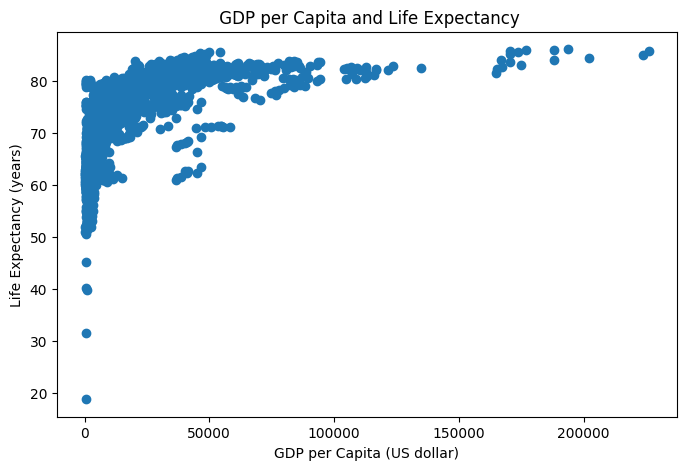

In [15]:
# Plot 2: Customized scatter plot of primary policy variables
plt.figure(figsize = (8,5))

plt.scatter(merge_df["gdp_per_capita"], merge_df["life_expectancy"], marker="o")

plt.title(" GDP per Capita and Life Expectancy")
plt.xlabel("GDP per Capita (US dollar)")
plt.ylabel("Life Expectancy (years)")

plt.show

In [16]:
# Fit a simple linear regression and overlay the line of best fit
X = merge_df[["gdp_per_capita"]]
X = sm.add_constant(X)
y = merge_df["life_expectancy"]

model = sm.OLS(y,X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     1170.
Date:                Tue, 16 Jun 2026   Prob (F-statistic):          2.48e-205
Time:                        00:59:52   Log-Likelihood:                -6990.5
No. Observations:                2165   AIC:                         1.399e+04
Df Residuals:                    2163   BIC:                         1.400e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             69.1489      0.158    437.

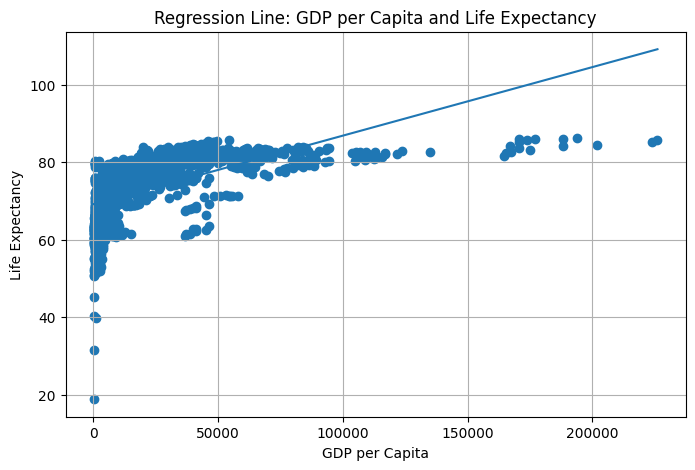

In [17]:
plt.figure(
    figsize=(8,5)
)


plt.scatter(
    merge_df["gdp_per_capita"],
    merge_df["life_expectancy"]
)


x_line = np.linspace(
    merge_df["gdp_per_capita"].min(),
    merge_df["gdp_per_capita"].max(),
    100
)


y_line = model.predict(
    sm.add_constant(
        pd.DataFrame(
            {
                "gdp_per_capita": x_line
            }
        )
    )
)


plt.plot(
    x_line,
    y_line
)


plt.title(
    "Regression Line: GDP per Capita and Life Expectancy"
)


plt.xlabel(
    "GDP per Capita"
)


plt.ylabel(
    "Life Expectancy"
)


plt.grid()


plt.show()

- The regression is based on the model:
  Life expectancy = beta0 + beta1 * GDP per capita + epsilon

  The estimated beta1 is 0.0002, which implies 1 dollar increase in GDP per capita is related to 0.0002 year higher life expectancy. The P value is smaller than 0.05, so the estimation is statistically significant.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.